## Library


In [ ]:
pip install ucimlrepo

In [ ]:
pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.0 MB/s eta 0:00:00


In [ ]:
from ucimlrepo import fetch_ucirepo
from ydata_profiling import ProfileReport
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

import missingno as msno
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

/tmp/ipykernel_2806/1251822127.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## EDA

In [ ]:
df = pd.read_csv('ckd.csv')

In [ ]:
df['class'] = df['class'].replace({'ckd\t': 'ckd', ' notckd': 'notckd'})
df['dm'] = df['dm'].replace({'\tno' : 'no'})

In [ ]:
df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [ ]:
print(df.shape)
print(df.dtypes)

(400, 25)
age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc       object
pc        object
pcc       object
ba        object
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn       object
dm        object
cad       object
appet     object
pe        object
ane       object
class     object
dtype: object


### EDA Lengkap

In [ ]:
# df_eda = df.copy()
# profile = ProfileReport(df_eda, title="CKD EDA Report", explorative=True)
# profile.to_file("ckd_eda.html")

### Deskripsi Statistik

In [ ]:
df.describe().round(2)

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.00,388.00,353.00,354.00,351.00,356.00,381.00,383.00,313.00,312.00,348.00,329.00,294.00,269.00
mean,51.48,76.47,1.02,1.02,0.45,148.04,57.43,3.07,137.53,4.63,12.53,38.88,8406.12,4.71
std,17.17,13.68,0.01,1.35,1.10,79.28,50.50,5.74,10.41,3.19,2.91,8.99,2944.47,1.03
min,2.00,50.00,1.00,0.00,0.00,22.00,1.50,0.40,4.50,2.50,3.10,9.00,2200.00,2.10
25%,42.00,70.00,1.01,0.00,0.00,99.00,27.00,0.90,135.00,3.80,10.30,32.00,6500.00,3.90
50%,55.00,80.00,1.02,0.00,0.00,121.00,42.00,1.30,138.00,4.40,12.65,40.00,8000.00,4.80
75%,64.50,80.00,1.02,2.00,0.00,163.00,66.00,2.80,142.00,4.90,15.00,45.00,9800.00,5.40
max,90.00,180.00,1.02,5.00,5.00,490.00,391.00,76.00,163.00,47.00,17.80,54.00,26400.00,8.00


### Pasien termuda dengan penyakit ginjal kronis.

In [ ]:
print(df[df['age'] == 2].T)

              215
age           2.0
bp            NaN
sg           1.01
al            3.0
su            0.0
rbc        normal
pc       abnormal
pcc    notpresent
ba     notpresent
bgr           NaN
bu            NaN
sc            NaN
sod           NaN
pot           NaN
hemo          NaN
pcv           NaN
wbcc          NaN
rbcc          NaN
htn            no
dm             no
cad            no
appet        good
pe            yes
ane            no
class         ckd


Terdapat temuan menarik, pasien termuda dengan umur 2 tahun terkena penyakit ginjal kronis. Setelah diteliti, hal ini berkaitan dengan berat jenis urin yang dimiliki pasien yaitu 1.01 yang mana mayoritas pasien PGK memiliki berat jenis urin di 1.01.

### Jumlah pasien dengan PGK dan tidak

In [ ]:
print(f'Dari {df.shape[0]} pasien, sebanyak {len(df[df['class'] == 'ckd'])/df.shape[0] * 100}% merupakan pasien dengan penyakit ginjal kronis.')

Dari 400 pasien, sebanyak 62.5% merupakan pasien dengan penyakit ginjal kronis.


### Distribusi Umur Pasien PGK

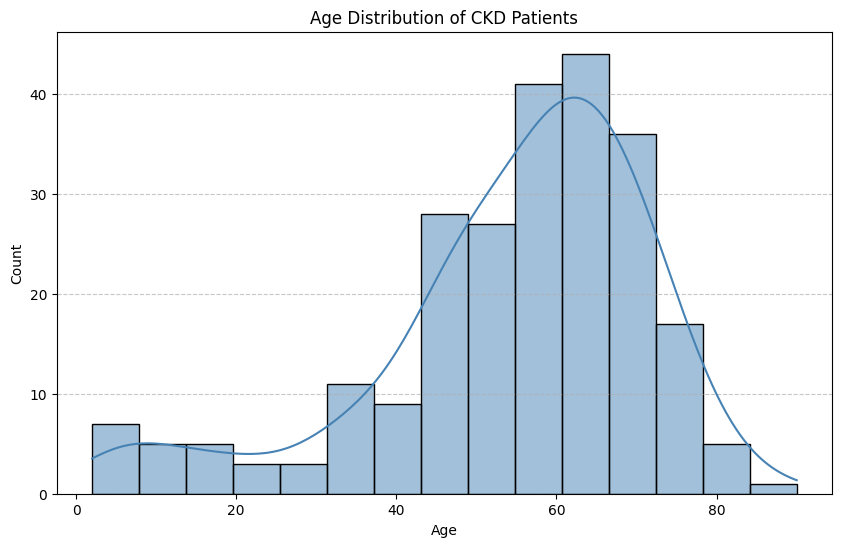

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df[df['class'] == 'ckd'], x='age', kde=True, color='steelblue')
plt.title('Age Distribution of CKD Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribusi jumlah sel darah merah

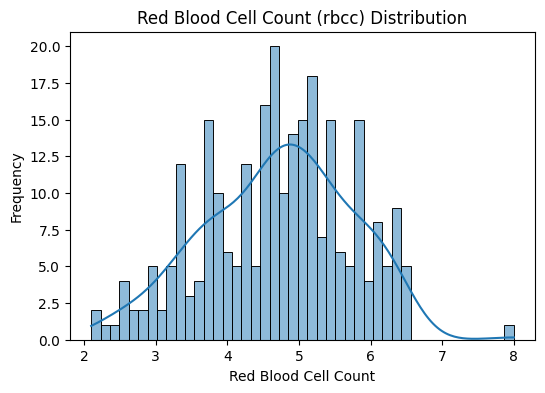

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='rbcc', palette='viridis', bins=45, kde=True)
plt.title('Red Blood Cell Count (rbcc) Distribution')
plt.xlabel('Red Blood Cell Count')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df[df['rbcc'] == 8]

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
133,70.0,100.0,1.015,4.0,0.0,normal,normal,notpresent,notpresent,118.0,...,37.0,8400.0,8.0,yes,no,no,good,no,no,ckd


Terdapat 1 orang dengan jumlah sel darah merah sebanyak 8 juta sel/mm^3. Namun anehnya pada kolom rbc (Sel darah merah) dikatakan sebagai normal. Tentunya kasus seperti ini memerlukan perhatian khusus untuk lebih diteliti oleh bidangnya.

### Distribusi Tekanan Darah

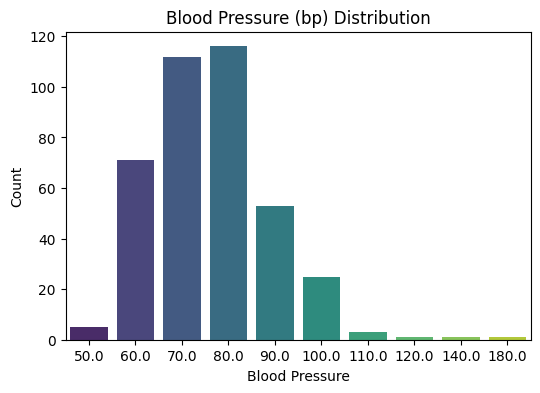

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='bp', palette='viridis')
plt.title('Blood Pressure (bp) Distribution')
plt.xlabel('Blood Pressure')
plt.ylabel('Count')
plt.show()

Terdapat beberapa pasien yang memiliki tekanan darah tidak normal seperti 50 mmHg dan 180 mmHg. Kondisi yang diidentifikasi ini dapat digunakan sebagai pengambilan keputusan bahwa pasien butuh perhatian yang khusus.

### Berat Jenis Urin dengan Penyakit Ginjal Kronis

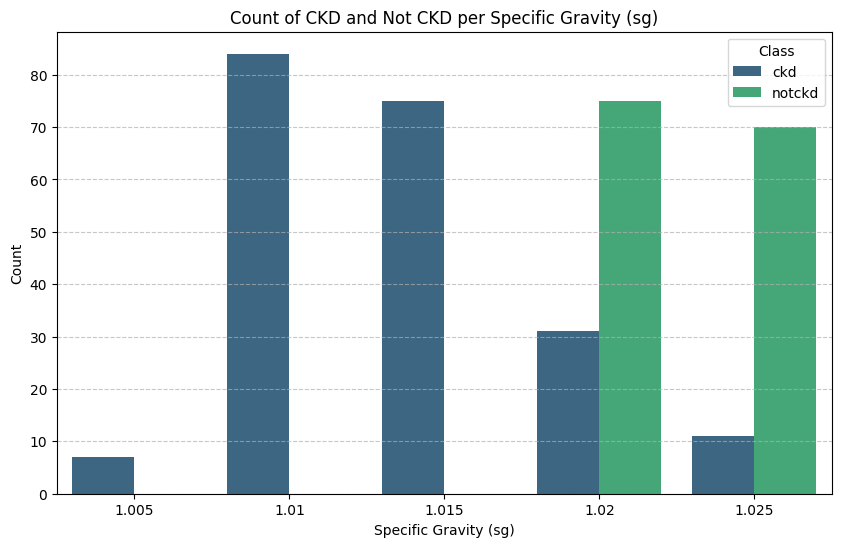

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sg', hue='class', palette='viridis')
plt.title('Count of CKD and Not CKD per Specific Gravity (sg)')
plt.xlabel('Specific Gravity (sg)')
plt.ylabel('Count')
plt.legend(title='Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Semakin bertambahnya nilai dari berat jenis urin maka besar juga kemungkinan untuk tidak terkena penyakit ginjal kronis

### Tabel Kontingen Nafsu Makan dan Diabetes terhadap PGK

In [ ]:
contingency_table = pd.crosstab(index=df['appet'], columns=[df['dm'], df['class']])
contingency_table

dm     no        yes
class ckd notckd ckd
appet               
good   84    147  84
poor   29      0  53

Berdasarkan data, semua pasien dengan riwayat non diabetes dan memiliki nafsu makan yang buruk terkena penyakit ginjal kronis. Namun disisi lain, Pasien dengan non-diabetes dan memiliki nafsu makan yang baik pun tetap banyak yang terkena penyakit ginjal kronis meski 42% lebih sedikit dibanding yang tidak terkena penyakit ginjal kornis. Data juga menunjukkan semua orang dengan riwayat diabetes baik memiliki nafsu makan baik atau buruk semuanya terkena penyakit ginjal kronis. Hal ini dapat berarti bahwa riwayat diabetes mungkin saja merupakan faktor penyebab penyakit ginjal kronis

### Missing value

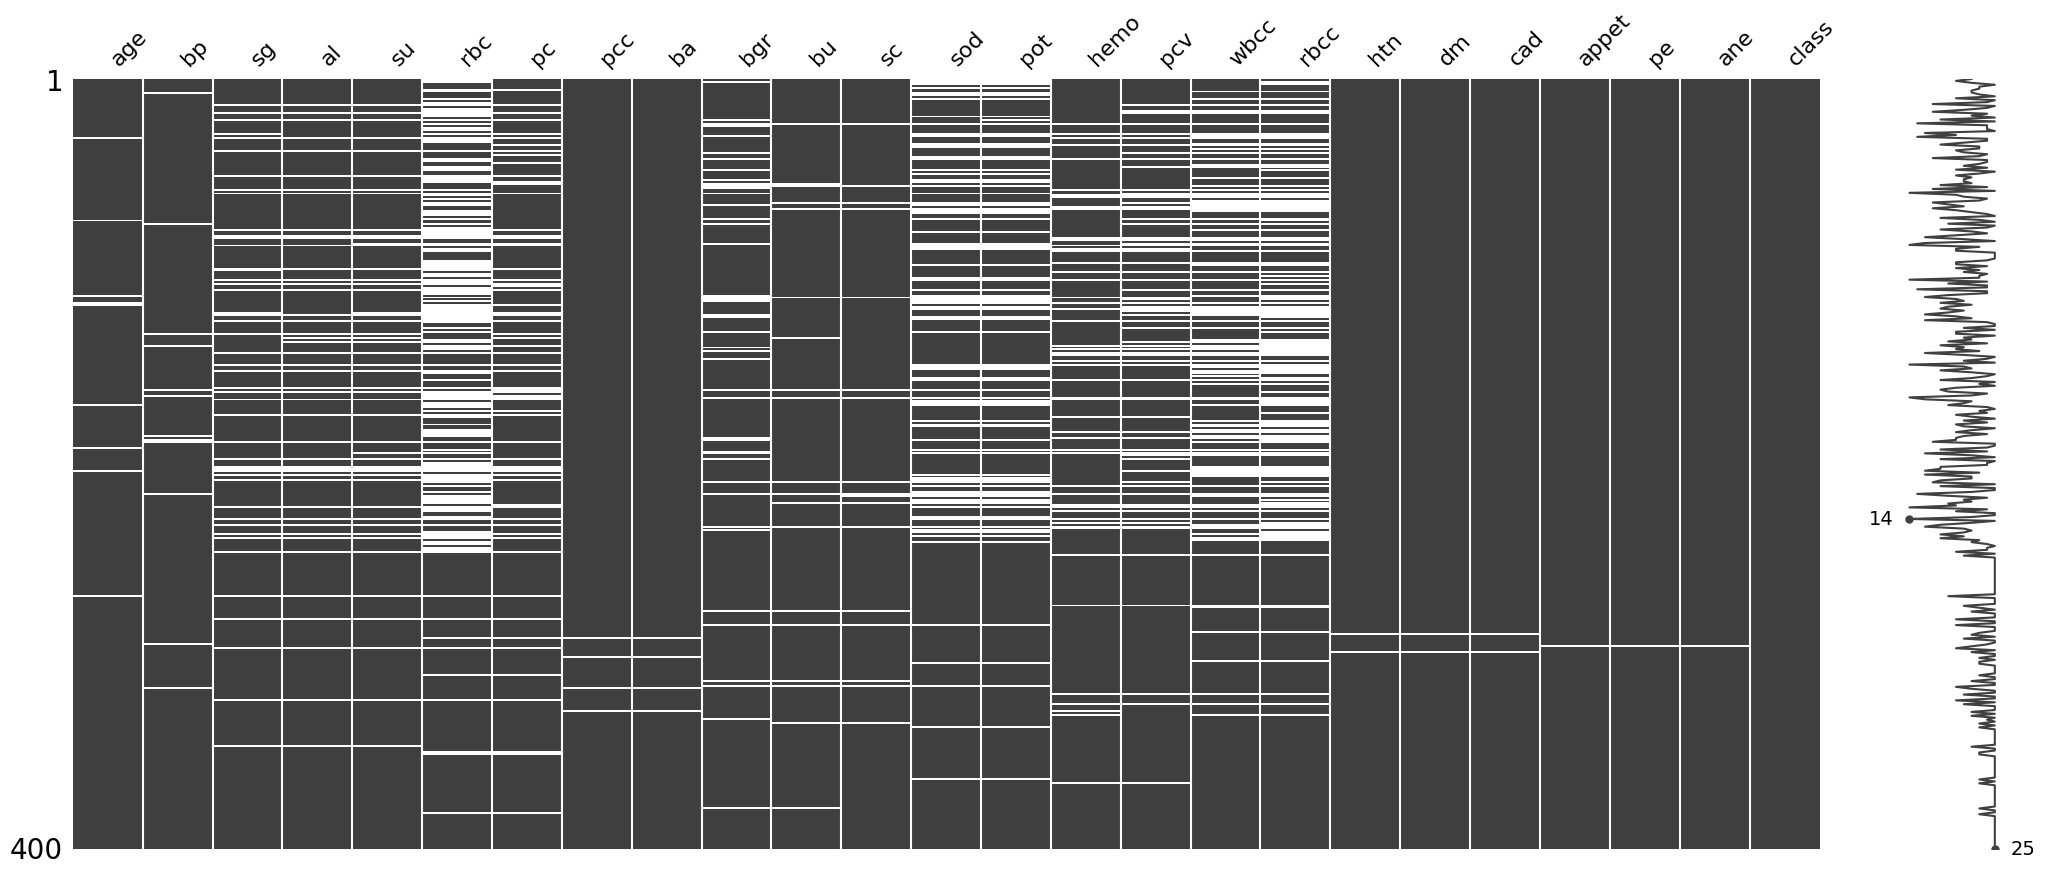

rbc      38.00
rbcc     32.75
wbcc     26.50
pot      22.00
sod      21.75
pcv      17.75
pc       16.25
hemo     13.00
su       12.25
sg       11.75
al       11.50
bgr      11.00
bu        4.75
sc        4.25
bp        3.00
age       2.25
pcc       1.00
ba        1.00
htn       0.50
dm        0.50
cad       0.50
appet     0.25
pe        0.25
ane       0.25
dtype: float64


In [ ]:
msno.matrix(df)
plt.show()

# Persentase missing per kolom
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

## Data Preprocessing

### Categorical to Numeric

In [ ]:
df['sg'] = pd.to_numeric(df['sg'], errors='coerce')

yesno_column = ['pe', 'ane', 'cad', 'dm', 'htn']
yesno = {'no': 0, 'yes': 1}
for column in yesno_column:
  df[column] = df[column].map(yesno)

presentnotpresent_column = ['pcc', 'ba']
presentnotpresent = {'notpresent': 0, 'present': 1}
for column in presentnotpresent_column:
  df[column] = df[column].map(presentnotpresent)

normalabnormal_column = ['rbc', 'pc']
normalabnormal = {'normal': 0, 'abnormal': 1}
for column in normalabnormal_column:
  df[column] = df[column].map(normalabnormal)

goodpoor_column =['appet']
goodpoor = {'good': 0, 'poor': 1}
for column in goodpoor_column:
  df[column] = df[column].map(goodpoor)

df['class'] = df['class'].map({'ckd': 1, 'notckd': 0})

In [ ]:
correlations = df.corr()['class'].abs().sort_values(ascending=False)
high_correlation_cols = correlations[correlations > 0.5]
print(high_correlation_cols)

class    1.000000
hemo     0.768919
pcv      0.741427
sg       0.732163
rbcc     0.699089
al       0.627090
htn      0.588820
dm       0.557444
rbc      0.555097
Name: class, dtype: float64


### Menginisialisasi data fitur dan data label

In [ ]:
X = df.drop('class', axis=1)
y = df['class']

### Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Handle Missing dengan Persentase Missing <30%

In [ ]:
imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42, n_jobs=1), random_state=42)
feature_names = X.columns.tolist()
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_names)
X_test  = pd.DataFrame(imputer.transform(X_test), columns=feature_names)

### Teknik Resampling menggunakan SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train, y_train = X_train_res, y_train_res

### K Fold Stratified

In [ ]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Modeling

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=1)
}

## Evaluation

### Confusion Matrix

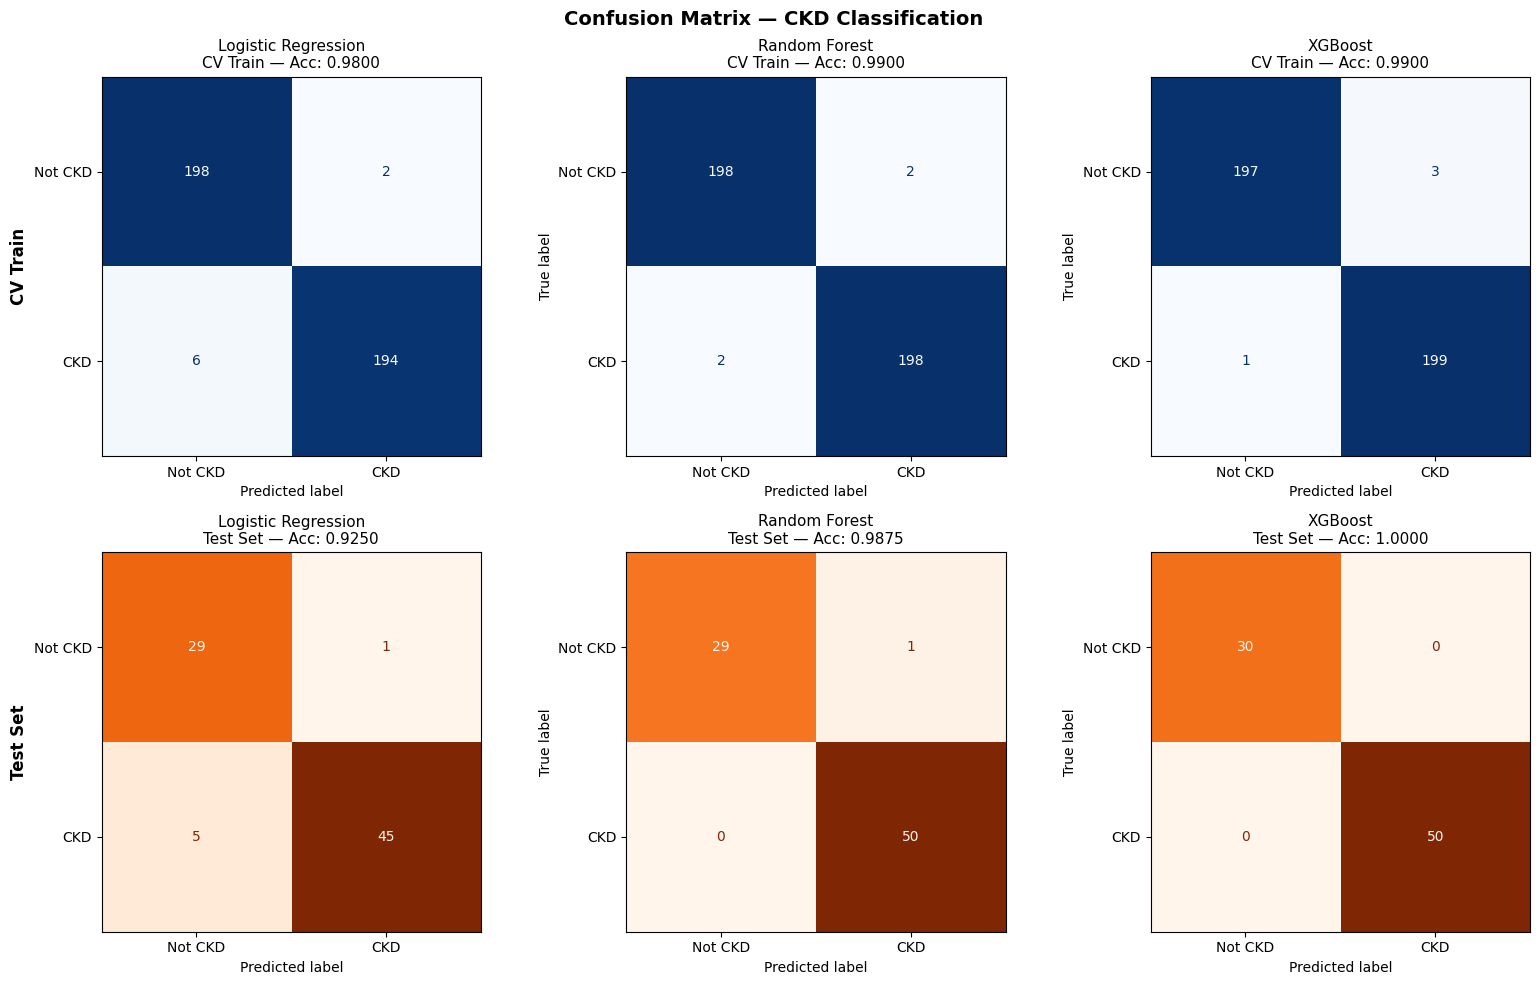

In [ ]:
cv_preds = {}
test_preds = {}
cv_accs = {}
test_accs = {}

for name, model in models.items():
    cv_preds[name]  = cross_val_predict(model, X_train, y_train, cv=kfold)
    cv_accs[name]   = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

    final_model = clone(model)
    final_model.fit(X_train, y_train)
    test_preds[name] = final_model.predict(X_test)
    test_accs[name]  = accuracy_score(y_test, test_preds[name])
    models[name] = final_model

# ========== CONFUSION MATRIX ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrix — CKD Classification', fontsize=14, fontweight='bold')

for col, name in enumerate(models.keys()):
    cm_cv = confusion_matrix(y_train, cv_preds[name])
    disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=['Not CKD', 'CKD'])
    disp_cv.plot(ax=axes[0, col], colorbar=False, cmap='Blues')
    axes[0, col].set_title(f'{name}\nCV Train — Acc: {cv_accs[name]:.4f}', fontsize=11)

    cm_test = confusion_matrix(y_test, test_preds[name])
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Not CKD', 'CKD'])
    disp_test.plot(ax=axes[1, col], colorbar=False, cmap='Oranges')
    axes[1, col].set_title(f'{name}\nTest Set — Acc: {test_accs[name]:.4f}', fontsize=11)

axes[0, 0].set_ylabel('CV Train', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Test Set', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Classification report

In [ ]:
print("=" * 70)
print("CLASSIFICATION REPORT COMPARISON — CV TRAIN vs TEST SET")
print("=" * 70)

for name in models.keys():
    print(f"\n{'▶ ' + name:}")
    print("-" * 35)

    print("📊 CV TRAIN:")
    print(classification_report(y_train, cv_preds[name], target_names=['Not CKD', 'CKD']))

    print("🧪 TEST SET:")
    print(classification_report(y_test, test_preds[name], target_names=['Not CKD', 'CKD']))

    print("=" * 70)

CLASSIFICATION REPORT COMPARISON — CV TRAIN vs TEST SET

▶ Logistic Regression
-----------------------------------
📊 CV TRAIN:
              precision    recall  f1-score   support

     Not CKD       0.97      0.99      0.98       200
         CKD       0.99      0.97      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

🧪 TEST SET:
              precision    recall  f1-score   support

     Not CKD       0.85      0.97      0.91        30
         CKD       0.98      0.90      0.94        50

    accuracy                           0.93        80
   macro avg       0.92      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80


▶ Random Forest
-----------------------------------
📊 CV TRAIN:
              precision    recall  f1-score   support

     Not CKD       0.99      0.99      0.99       200
         CKD       0.99      0.99

### AUC-ROC

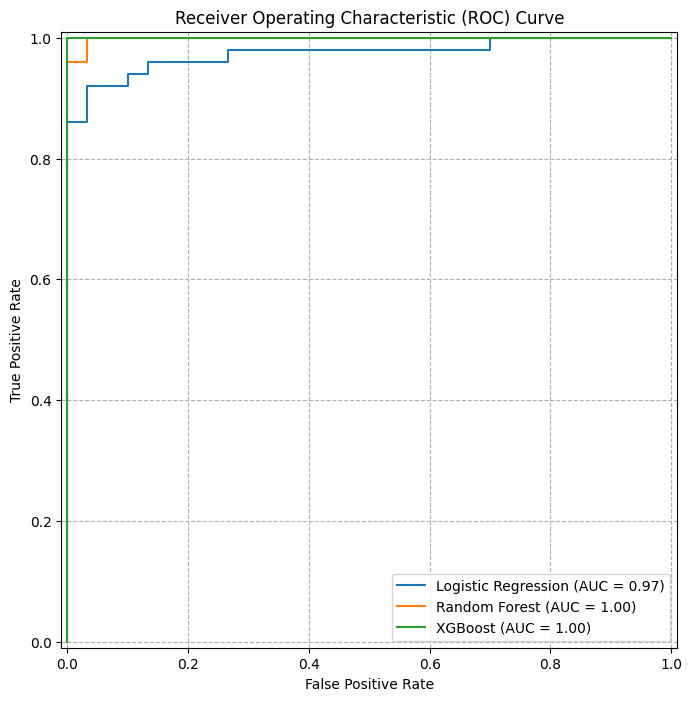

In [ ]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(linestyle='--')
plt.show()

In [ ]:
import pickle

impute_col = X_train.columns[X_train.isnull().any()].tolist()

bundle = {
    'model': models['XGBoost'],
    'impute_col': list(impute_col),
    'feature_names': list(X.columns)
}

with open('best_model_xgb.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("✅ Model bundle tersimpan!")

✅ Model bundle tersimpan!


In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(models['XGBoost'], X_test, y_test, n_repeats=10, random_state=42)
feat_imp = pd.Series(result.importances_mean, index=feature_names)
print(feat_imp.sort_values(ascending=False).head(10))

rbc     0.20500
hemo    0.06875
bu      0.01250
al      0.01000
sg      0.01000
su      0.00000
age     0.00000
bp      0.00000
pcc     0.00000
pc      0.00000
dtype: float64
